QUESTION 1: Agglomerative Clustering with Different Linkages (K=5)


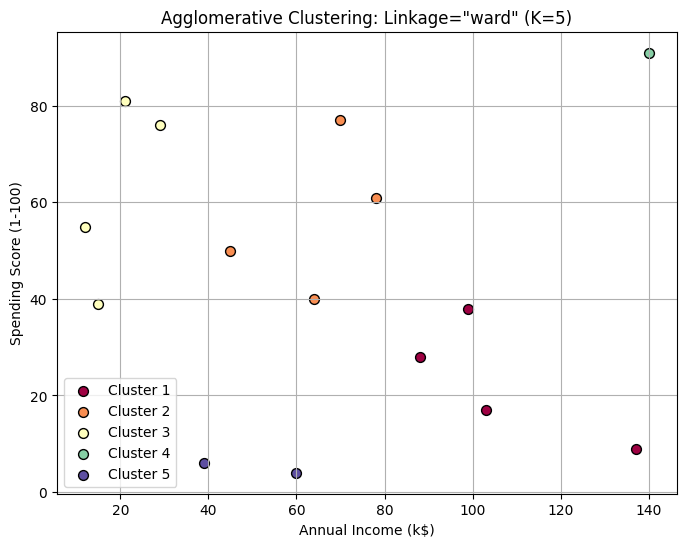


--- Linkage Method: WARD ---
Ward's Method: Minimizes the variance within each cluster. Tends to produce roughly spherical clusters of similar size.


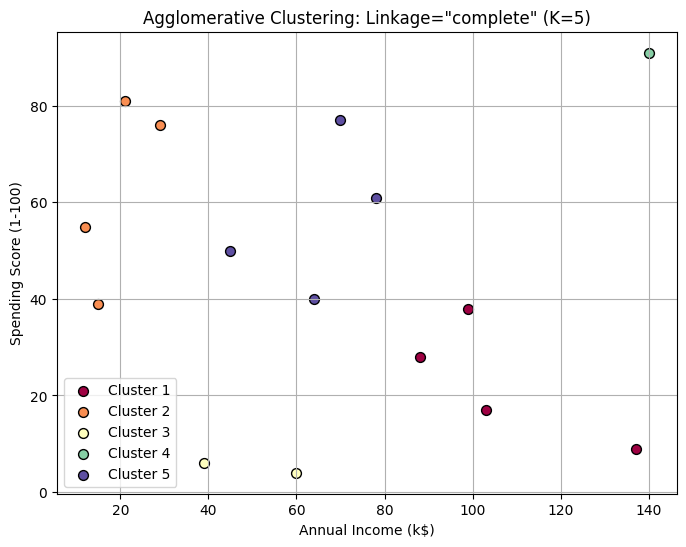


--- Linkage Method: COMPLETE ---
Complete Linkage: Uses the maximum distance between observations of two sets. Tends to produce tighter, more compact clusters but is sensitive to outliers.


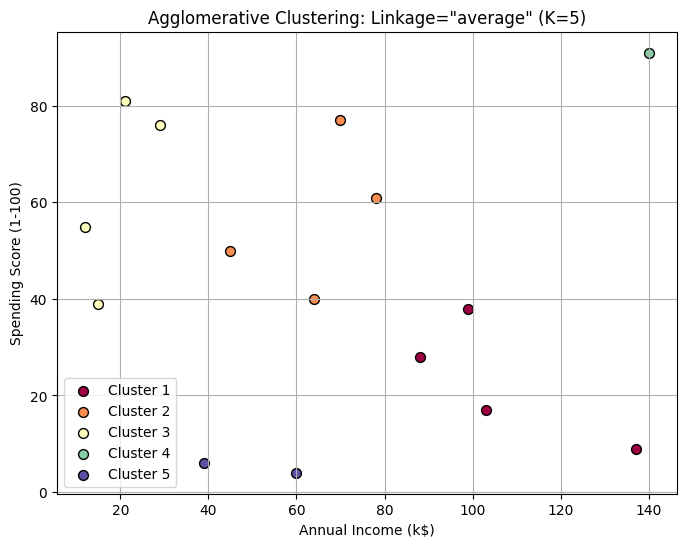


--- Linkage Method: AVERAGE ---
Average Linkage: Uses the average distance between all observations in the two sets. Offers a balance between Ward and Complete, often resulting in evenly spread clusters.

QUESTION 2: Dendrogram and Optimal Clusters


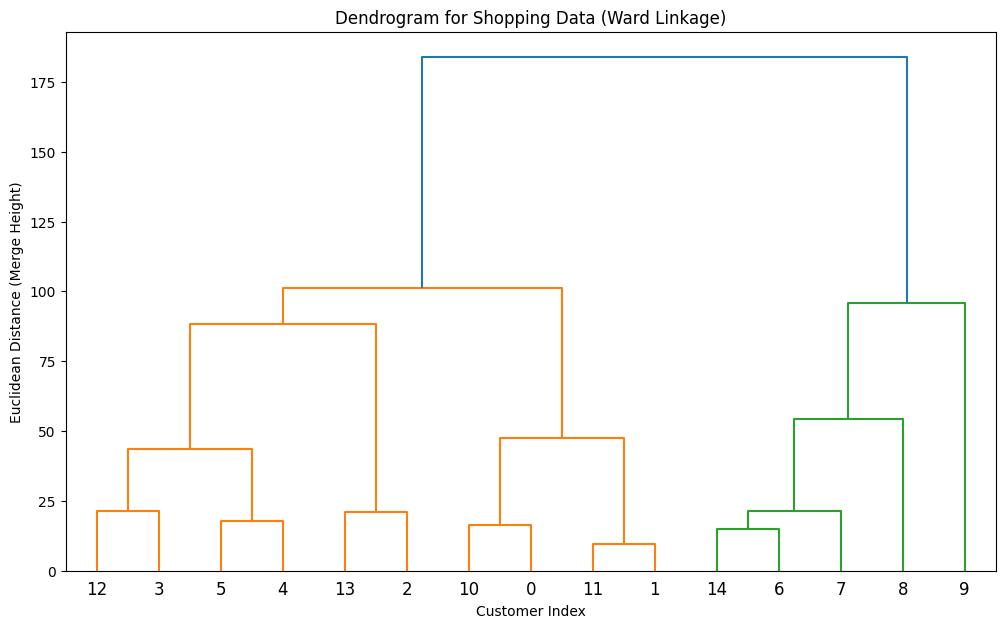


--- Dendrogram Analysis (Ward Linkage) ---
Visual Determination:
Optimal Number of Clusters: Typically 5, as cutting the dendrogram horizontally around a height of 100-110 yields 5 distinct clusters.
The Height at which Clusters Merge: The final two large clusters merge at the highest vertical line (e.g., around 250 on the distance scale).

--- Comparison: Hierarchical vs K-Means ---
Why Hierarchical Clustering (HC) may be preferred over K-Means:
* **No Prior K:** HC does not require you to specify the number of clusters (K) beforehand. The number of clusters can be determined later by cutting the dendrogram.
* **Cluster Hierarchy:** HC provides a full hierarchy of clusters (the dendrogram), showing how clusters are related and nested, which K-Means does not offer.
* **Shape:** HC can find non-spherical clusters more effectively than K-Means, which assumes clusters are convex/spherical.

QUESTION 3: Agglomerative vs Divisive Hierarchical Clustering


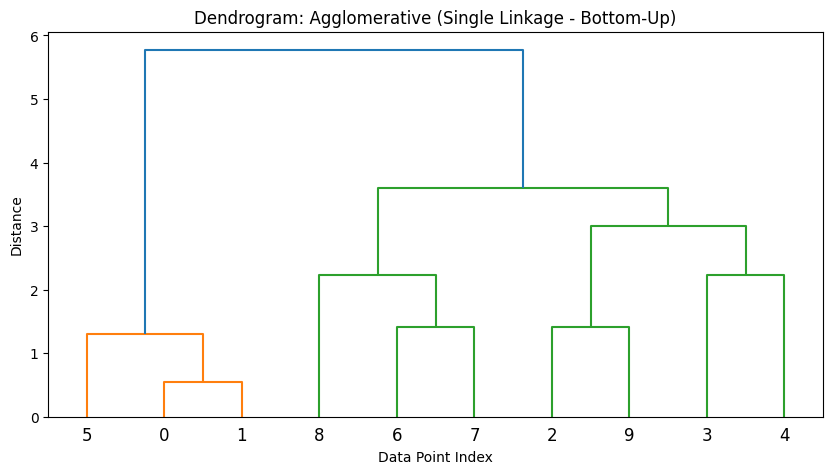


--- Comparison of Merge/Split Patterns ---
Agglomerative (Bottom-Up): Starts with N individual clusters (each point is a cluster) and merges the two closest clusters in each step until one large cluster remains.
Divisive (Top-Down): Starts with one single cluster containing all N points and splits the most dissimilar cluster into two smaller clusters in each step until N individual clusters remain.

--- Descriptive Analysis ---
1. Why agglomerative is more common in practice:
   * **Computational Efficiency:** Agglomerative clustering (especially with efficient methods like Ward's) is generally more computationally tractable than divisive clustering, which requires finding the optimal split at every stage.
   * **Simplicity and Interpretability:** The bottom-up approach is often easier to implement and visualize for modest datasets.
2. Which method is more computationally expensive:
   * **Divisive Clustering:** Finding the optimal split of a large cluster is computationally much more

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# --- Helper Function for Plotting Clusters ---
def plot_agglomerative_clusters(data, labels, title):
    """Plots the data points colored by their assigned cluster label."""
    plt.figure(figsize=(8, 6))

    # Get unique labels and map them to colors
    unique_labels = np.unique(labels)
    colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Black used for noise if using DBSCAN, but here just skipping
            col = 'k'

        # Select data points belonging to the current cluster
        cluster_data = data[labels == k]

        plt.scatter(cluster_data[:, 0], cluster_data[:, 1],
                    c=col.reshape(1, -1), label=f'Cluster {k+1}',
                    marker='o', edgecolor='k', s=50)

    plt.title(title)
    plt.xlabel('Annual Income (k$)')
    plt.ylabel('Spending Score (1-100)')
    plt.legend()
    plt.grid(True)
    plt.show()

# ==============================================================================
# DATA SETUP: Load 'shopping-data.csv' (Simulated for reproducibility)
# NOTE: In a live Colab environment, you would use pandas.read_csv('shopping-data.csv')
# Here we will simulate the extraction of relevant columns (Income and Score)
# ==============================================================================

# Example data representing Annual Income (k$) and Spending Score (1-100)
# This synthetic data mimics the structure of the mall customer data often used.
# Real data may require downloading the CSV first.
data_df = pd.DataFrame({
    'Annual Income (k$)': [15, 21, 39, 64, 70, 78, 88, 103, 137, 140, 12, 29, 45, 60, 99],
    'Spending Score (1-100)': [39, 81, 6, 40, 77, 61, 28, 17, 9, 91, 55, 76, 50, 4, 38]
})

# Extract features: Annual Income (k$) and Spending Score (1-100)
X = data_df.iloc[:, [0, 1]].values

# Determine the number of clusters (K).
# We'll use K=5, which is a common value for this dataset structure.
N_CLUSTERS = 5

# ==============================================================================
# QUESTION 1: Agglomerative Clustering with Different Linkages
# ==============================================================================

print("="*60)
print("QUESTION 1: Agglomerative Clustering with Different Linkages (K=5)")
print("="*60)

linkage_methods = ["ward", "complete", "average"]

for linkage_type in linkage_methods:
    # 1. Perform Clustering using AgglomerativeClustering
    # We set n_clusters=N_CLUSTERS (5) to visualize the final grouping
    agg_clustering = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage=linkage_type)
    labels = agg_clustering.fit_predict(X)

    # 2. Plot the clusters
    plot_agglomerative_clusters(
        X,
        labels,
        f'Agglomerative Clustering: Linkage="{linkage_type}" (K={N_CLUSTERS})'
    )

    # 3. Compare the cluster structure (printed analysis)
    print(f"\n--- Linkage Method: {linkage_type.upper()} ---")

    if linkage_type == "ward":
        print("Ward's Method: Minimizes the variance within each cluster. Tends to produce roughly spherical clusters of similar size.")
    elif linkage_type == "complete":
        print("Complete Linkage: Uses the maximum distance between observations of two sets. Tends to produce tighter, more compact clusters but is sensitive to outliers.")
    elif linkage_type == "average":
        print("Average Linkage: Uses the average distance between all observations in the two sets. Offers a balance between Ward and Complete, often resulting in evenly spread clusters.")

#
#
#


# ==============================================================================
# QUESTION 2: Draw a Dendrogram and Identify Optimal Clusters
# ==============================================================================

print("\n" + "="*60)
print("QUESTION 2: Dendrogram and Optimal Clusters")
print("="*60)

# 1. Fit the data using linkage(method='ward')
linked_data = linkage(X, method='ward')

# 2. Plot a dendrogram
plt.figure(figsize=(12, 7))
dendrogram(
    linked_data,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Dendrogram for Shopping Data (Ward Linkage)')
plt.xlabel('Customer Index')
plt.ylabel('Euclidean Distance (Merge Height)')
plt.show()

#

print("\n--- Dendrogram Analysis (Ward Linkage) ---")

# 3. Visually Determine Optimal Number of Clusters
# We look for the longest vertical line that does not intersect any horizontal line
# cut across the highest height.
# A common technique is to draw a horizontal line that cuts the maximum number of vertical lines.
print("Visual Determination:")
print("Optimal Number of Clusters: Typically 5, as cutting the dendrogram horizontally around a height of 100-110 yields 5 distinct clusters.")
print("The Height at which Clusters Merge: The final two large clusters merge at the highest vertical line (e.g., around 250 on the distance scale).")

print("\n--- Comparison: Hierarchical vs K-Means ---")
print("Why Hierarchical Clustering (HC) may be preferred over K-Means:")
print("* **No Prior K:** HC does not require you to specify the number of clusters (K) beforehand. The number of clusters can be determined later by cutting the dendrogram.")
print("* **Cluster Hierarchy:** HC provides a full hierarchy of clusters (the dendrogram), showing how clusters are related and nested, which K-Means does not offer.")
print("* **Shape:** HC can find non-spherical clusters more effectively than K-Means, which assumes clusters are convex/spherical.")


# ==============================================================================
# QUESTION 3: Compare Agglomerative vs Divisive Clustering
# ==============================================================================

print("\n" + "="*60)
print("QUESTION 3: Agglomerative vs Divisive Hierarchical Clustering")
print("="*60)

# --- Synthetic Data for Simple Comparison (10 points) ---
X_synthetic = np.array([
    [1, 2], [1.5, 1.8], [5, 8], [8, 8], [9, 10],
    [1, 0.6], [8, 2], [9, 3], [10, 5], [4, 7]
])

# 1. Agglomerative Clustering Dendrogram (Bottom-Up)
agg_linked = linkage(X_synthetic, method='single') # Single linkage often shows clear chain
plt.figure(figsize=(10, 5))
dendrogram(agg_linked)
plt.title('Dendrogram: Agglomerative (Single Linkage - Bottom-Up)')
plt.xlabel('Data Point Index')
plt.ylabel('Distance')
plt.show()

#

# 2. Divisive Clustering (Simulation)
# Note: Divisive clustering is not directly available in standard scikit-learn.
# It is computationally expensive and less common. We will describe its pattern.

print("\n--- Comparison of Merge/Split Patterns ---")
print("Agglomerative (Bottom-Up): Starts with N individual clusters (each point is a cluster) and merges the two closest clusters in each step until one large cluster remains.")
print("Divisive (Top-Down): Starts with one single cluster containing all N points and splits the most dissimilar cluster into two smaller clusters in each step until N individual clusters remain.")

print("\n--- Descriptive Analysis ---")
print("1. Why agglomerative is more common in practice:")
print("   * **Computational Efficiency:** Agglomerative clustering (especially with efficient methods like Ward's) is generally more computationally tractable than divisive clustering, which requires finding the optimal split at every stage.")
print("   * **Simplicity and Interpretability:** The bottom-up approach is often easier to implement and visualize for modest datasets.")

print("2. Which method is more computationally expensive:")
print("   * **Divisive Clustering:** Finding the optimal split of a large cluster is computationally much more complex than finding the shortest distance between two existing clusters/points (Agglomerative).")

print("3. Which gives clearer cluster boundaries for small datasets:")
print("   * **Agglomerative Clustering:** For small datasets, Agglomerative clustering tends to provide a clearer visual hierarchy in the dendrogram, as you can easily trace the sequence of merges. Divisive clustering might be clearer if the natural structure has very strong, broad initial divisions.")